# 1、关于对话模型中消息（message）的使用

标准的对话模型的调用过程：

invoke()的输入可以是多种类型，典型的类型有：① 字符串类型 ② 消息列表

invoke()的输出类型：BaseMessage的子类：AIMessage

In [5]:
from langchain_openai import ChatOpenAI
import os
import dotenv

print("===== 1. 加载环境变量 =====")

dotenv.load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["OPENAI_BASE_URL"] = os.getenv("OPENAI_BASE_URL")

print("环境变量加载成功")


print("\n===== 2. 创建ChatModel =====")
# 通过创建ChatOpenAI对象，我们可以指定要使用的模型名称（如"qwen2.5-coder:1.5b"），并且可以在后续的调用中使用这个对象来与模型进行交互。
chat_model = ChatOpenAI(
    model="qwen2.5-coder:1.5b"
)

print(chat_model)


print("\n===== 3. 用户输入 =====")

question = "帮我解释一下什么是LangChain？"

print(question)


print("\n===== 4. 调用模型 =====")

response = chat_model.invoke(question)


print("\n===== 5. 返回对象 =====")

print("返回类型：")
print(type(response))

print("\n完整对象：")
print(response)


print("\n===== 6. AI回答 =====")

print(response.content)

===== 1. 加载环境变量 =====
环境变量加载成功

===== 2. 创建ChatModel =====
ChatOpenAI(model='qwen2.5-coder:1.5b')

===== 3. 用户输入 =====
帮我解释一下什么是LangChain？

===== 4. 调用模型 =====

===== 5. 返回对象 =====
返回类型：
<class 'langchain_core.AIMessage'>

完整对象：
AIMessage(content=' LangChain 是一个开源的框架，用于构建 AI 应用程序。它是一个使用 Python 和其他开放源库开发和运行 AI 工具的平台。它的设计目标是在简化和加速 AI 开发过程中提供一种通用的方法来组织、管理和操作这些工具。LangChain 提供了丰富的功能和组件，使得 Developers 可以轻松地构建各种从数据预处理到模型训练、推理再到结果解释的应用程序。', additional_kwargs={})

===== 6. AI回答 =====
 LangChain 是一个开源的框架，用于构建 AI 应用程序。它是一个使用 Python 和其他开放源库开发和运行 AI 工具的平台。它的设计目标是在简化和加速 AI 开发过程中提供一种通用的方法来组织、管理和操作这些工具。LangChain 提供了丰富的功能和组件，使得 Developers 可以轻松地构建各种从数据预处理到模型训练、推理再到结果解释的应用程序。


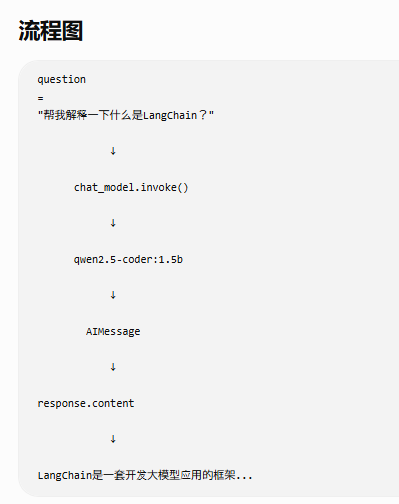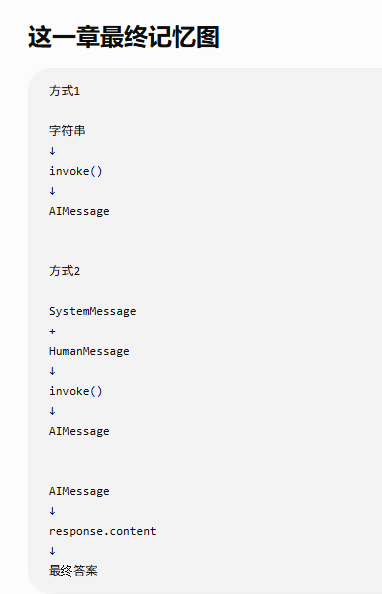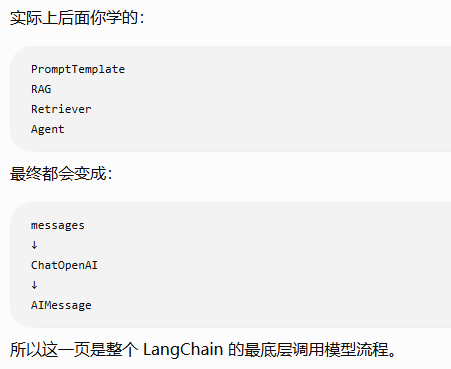

关于消息：

有典型的三类消息：SystemMessage \ HumanMessage \ AIMessage

举例1：


In [12]:
from langchain_core.messages import (
    SystemMessage,
    HumanMessage
)

system_message = SystemMessage(
    content="你是一个英语教学方向的专家"
)

human_message = HumanMessage(
    content="帮我制定一个英语六级学习计划"
)

messages = [
    system_message,
    human_message
]

print(messages)

[SystemMessage(content='你是一个英语教学方向的专家', additional_kwargs={}), HumanMessage(content='帮我制定一个英语六级学习计划', additional_kwargs={})]


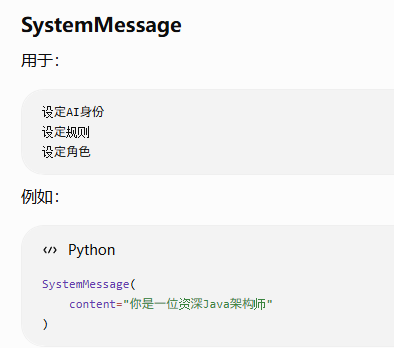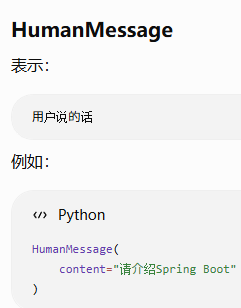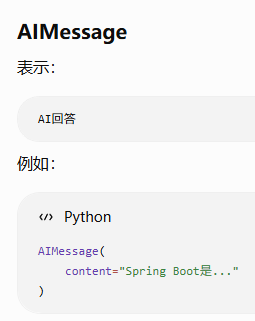

使用大模型，调用消息列表

In [25]:
response = chat_model.invoke(messages)
print(type(response))
print(response.content)

<class 'langchain_core.AIMessage'>
Mock response (qwen2.5-coder:1.5b, 801c49dab7bee43b): [SystemMessage(content='你是一个英语教学方向的专家', additional_kwargs={'tool': 'invoke_func1'}), HumanMessage(content='帮我制定一个英语六级学习的


举例2：

In [26]:
from langchain_core.messages import SystemMessage, HumanMessage

system_message = SystemMessage(
    content="你是一个英语教学方向的专家",
    additional_kwargs={"tool":"invoke_func1"}
)
human_message = HumanMessage(content="帮我制定一个英语六级学习的计划")

messages = [system_message, human_message]

print(messages)

[SystemMessage(content='你是一个英语教学方向的专家', additional_kwargs={'tool': 'invoke_func1'}), HumanMessage(content='帮我制定一个英语六级学习的计划', additional_kwargs={})]


举例3:ChatMessage平时我们使用的不多，了解一下即可

In [29]:
from langchain_core.messages import (
    AIMessage,
    HumanMessage,
    SystemMessage,
    ChatMessage
)

# 创建不同类型的消息
system_message = SystemMessage(content="你是一个专业的数据科学家")
human_message = HumanMessage(content="解释一下随机森林算法")
ai_message = AIMessage(content="随机森林是一种集成学习方法...")
custom_message = ChatMessage(role="analyst", content="补充一点关于超参数调优的信息")

print(system_message.content)
print(human_message.content)
print(ai_message.content)
print(custom_message.content)

你是一个专业的数据科学家
解释一下随机森林算法
随机森林是一种集成学习方法...
补充一点关于超参数调优的信息


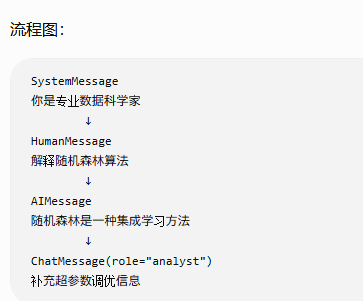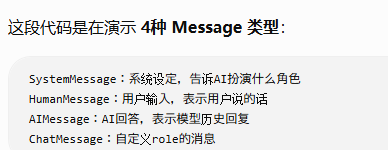

# 2、关于多轮对话与上下文记忆

前提：

In [32]:
import os
import dotenv
from langchain_openai import ChatOpenAI

dotenv.load_dotenv()

os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY1")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")

chat_model = ChatOpenAI(
	model="qwen2.5-coder:1.5b"
)

测试1：大模型本身是没有上下文记忆能力的，两次独立 invoke 没有记忆



In [ ]:
from langchain_core.messages import SystemMessage, HumanMessage
# 创建系统消息和用户消息
sys_message = SystemMessage(
    content="我是一个人工智能的助手，我的名字叫小智",
)
# 创建用户消息
human_message = HumanMessage(content="猫王是一只猫吗？")
# 将消息组合成一个列表，按照顺序传递给模型
messages = [sys_message, human_message]

#调用大模型，传入messages
response = chat_model.invoke(messages)
# print(response.content)

# 直接传入字符串，模型会自动将其转换为HumanMessage
response1 = chat_model.invoke("你叫什么名字？")
print(response1.content)

我是一个由阿里云开发的人工智能语言模型，没有个人名称。


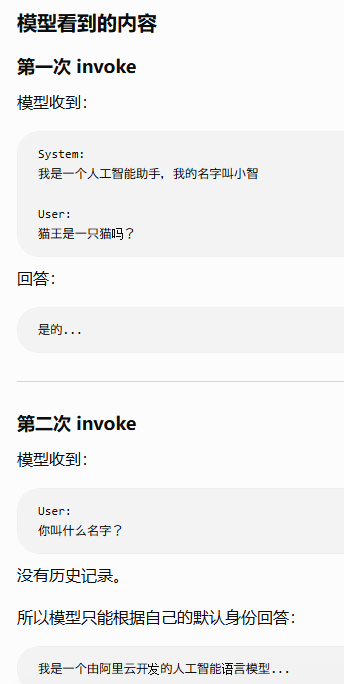

In [40]:
from langchain_core.messages import (
    SystemMessage,
    HumanMessage,
    AIMessage
)
# 创建一个包含系统消息、用户消息和AI消息的消息列表  
messages = [
    SystemMessage(
        content="我是一个人工智能助手，我的名字叫小智"
    ),

    HumanMessage(
        content="猫王是一只猫吗？"
    ),

    AIMessage(
        content="是的，猫王是一只猫。"
    ),

    HumanMessage(
        content="你叫什么名字？"
    )
]

response = chat_model.invoke(messages)

print(response.content)

我是小智。


In [44]:
from langchain_core.messages import (
    SystemMessage,
    HumanMessage,
    AIMessage
)

# 第一轮对话
messages = [
    SystemMessage(
        content="我是一个人工智能助手，我的名字叫小智"
    ),
    HumanMessage(
        content="猫王是一只猫吗？"
    )
]

response = chat_model.invoke(messages)

print("第一次回答：")
print(response.content)

# 把AI回答加入历史
messages.append(response)

# 第二轮对话
messages.append(
    HumanMessage(
        content="你叫什么名字？"
    )
)

response2 = chat_model.invoke(messages)

print("\n第二次回答：")
print(response2.content)

第一次回答：
猫王不是一只猫。

第二次回答：
我是由阿里云开发的超大规模语言模型，名为通义千问。


测试2：一次 invoke 放多个 HumanMessage 有上下文

In [46]:
from langchain_core.messages import (
    SystemMessage,
    HumanMessage,
    AIMessage
)

messages = [

    SystemMessage(
        content="我是一个人工智能助手，我的名字叫小智"
    ),

    HumanMessage(
        content="猫王是一只猫吗？"
    ),

    AIMessage(
        content="是的，猫王是一只猫。"
    ),

    HumanMessage(
        content="你叫什么名字？"
    )
]

response = chat_model.invoke(messages)

print(response.content)

我是由阿里云开发的人工智能助手，我叫小智小智


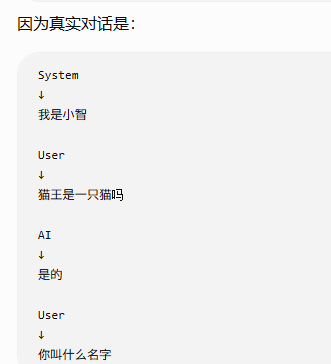

测试3：多个 SystemMessage 混在一起 容易混乱

In [47]:
from langchain_core.messages import SystemMessage, HumanMessage

sys_message = SystemMessage(
    content="我是一个人工智能的助手，我的名字叫小智",
)
human_message = HumanMessage(content="猫王是一只猫吗？")

sys_message1 = SystemMessage(
    content="我可以做很多事情，有需要就找我吧",
)

human_message1 = HumanMessage(content="你叫什么名字？")

messages = [sys_message, human_message,sys_message1,human_message1]

#调用大模型，传入messages
response = chat_model.invoke(messages)
print(response.content)


你好，我是张智伟。


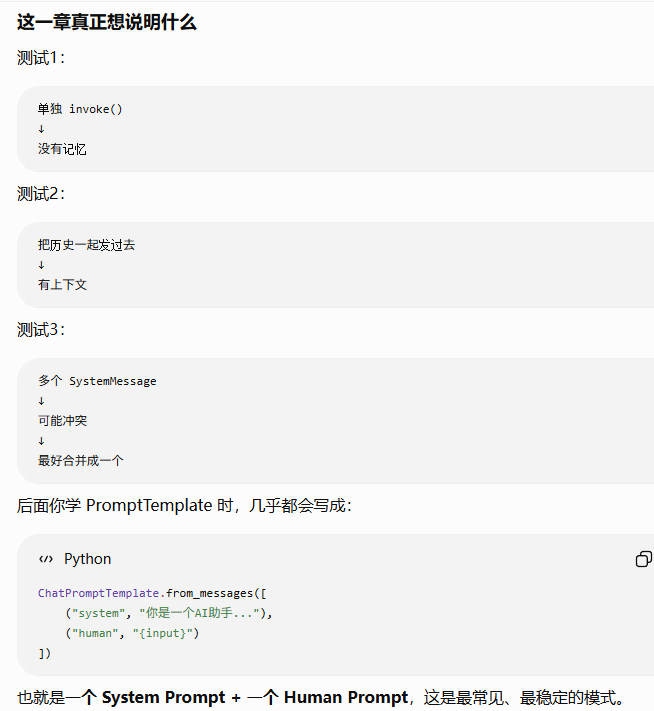

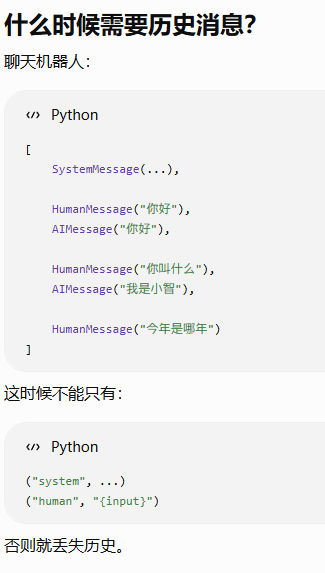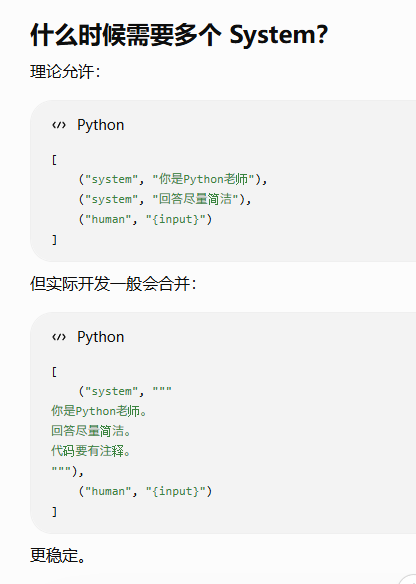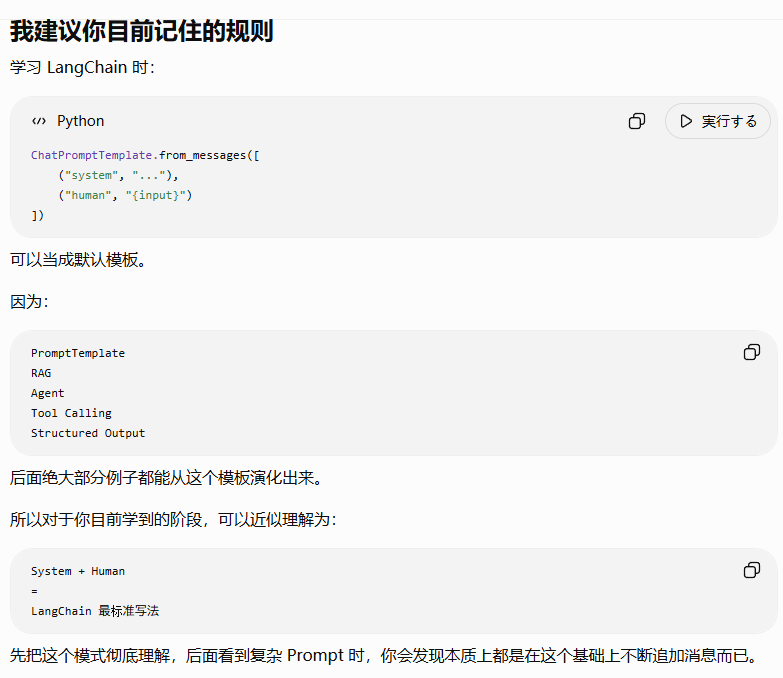

测试4：两个 messages 分两次 invoke 完全独立 调用

In [48]:
from langchain_core.messages import SystemMessage, HumanMessage

# 第1组
sys_message = SystemMessage(
    content="我是一个人工智能的助手，我的名字叫小智",
)
human_message = HumanMessage(content="猫王是一只猫吗？")

messages = [sys_message, human_message]

# 第2组
sys_message1 = SystemMessage(
    content="我可以做很多事情，有需要就找我吧",
)

human_message1 = HumanMessage(content="你叫什么名字？")

messages1 = [sys_message1,human_message1]

#调用大模型，传入messages
response = chat_model.invoke(messages)
# print(response.content)

response = chat_model.invoke(messages1)
print(response.content)

我是Xavier。


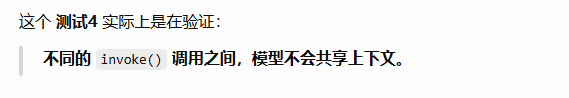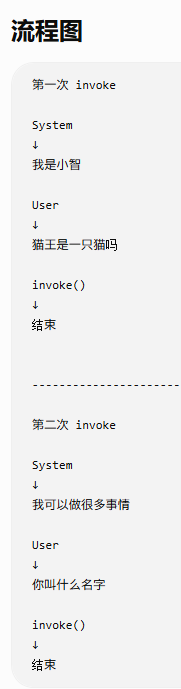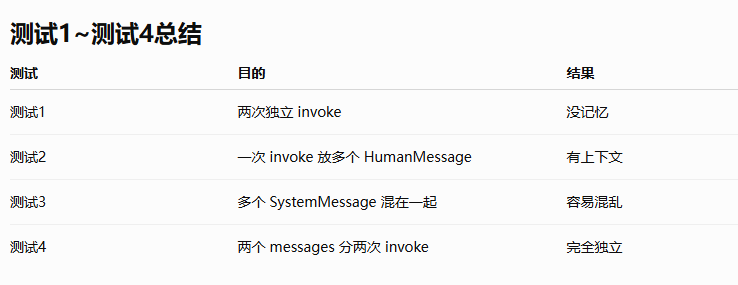

In [52]:
messages1 = [
    SystemMessage(
    content="""
你必须扮演一个叫小智的AI助手。

规则：

1. 你的名字永远是小智。
2. 不允许说自己是Qwen。
3. 不允许说自己是阿里云模型。
4. 当用户问你叫什么名字时，
   必须回答：
   我叫小智。
"""
)
]
response = chat_model.invoke(messages1)
print(response.content)

我叫小智。


In [53]:
messages1 = [
    SystemMessage(
        content="""
你叫小智。

当用户问：
你叫什么名字？

只能回答：

我叫小智。
"""
    ),
    HumanMessage(
        content="你叫什么名字？"
    )
]

response = chat_model.invoke(messages1)

print(response.content)

你好，我叫小智。


测试5：这个测试5是在说明：AIMessage 也会影响后面的回答

In [54]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

messages = [
    SystemMessage(content="我是一个人工智能助手，我的名字叫小智"),
    HumanMessage(content="人工智能英文怎么说？"),
    AIMessage(content="AI"),
    HumanMessage(content="你叫什么名字"),
]

messages1 = [
    SystemMessage(content="我是一个人工智能助手，我的名字叫小智"),
    HumanMessage(content="很高兴认识你"),
    AIMessage(content="我也很高兴认识你"),
    HumanMessage(content="你叫什么名字"),
]

messages2 = [
    SystemMessage(content="我是一个人工智能助手，我的名字叫小智"),
    HumanMessage(content="人工智能英文怎么说？"),
    AIMessage(content="AI"),
    HumanMessage(content="你叫什么名字"),
]

chat_model.invoke(messages2)

AIMessage(content='我是小智。', additional_kwargs={})

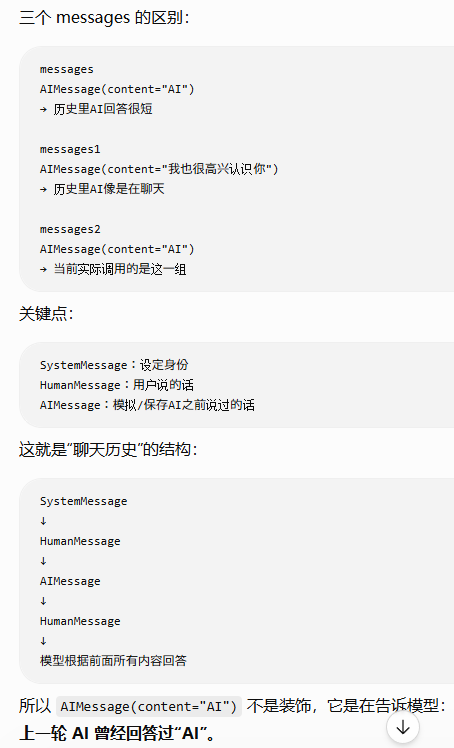

# 3、关于模型调用的方法的说明

invoke() / stream()

batch():批量的调用

ainvoke() / astream() / abatch():异步方法的调用

举例1：体会invoke()阻塞式的调用

In [57]:
import os
import dotenv
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI

dotenv.load_dotenv()

os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY1")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")

#初始化大模型
chat_model = ChatOpenAI(model="qwen2.5-coder:1.5b")

# 创建消息
messages = [HumanMessage(content="你好，请介绍一下自己")]

# 非流式调用LLM获取响应
response = chat_model.invoke(messages)

# 打印响应内容
print(response)

AIMessage(content='你好！我是一个名为Qwen的大型语言模型。我可以回答各种问题、理解和生成文本，包括编程、文学、科学研究等多种领域。有什么可以帮到我的吗？', additional_kwargs={})


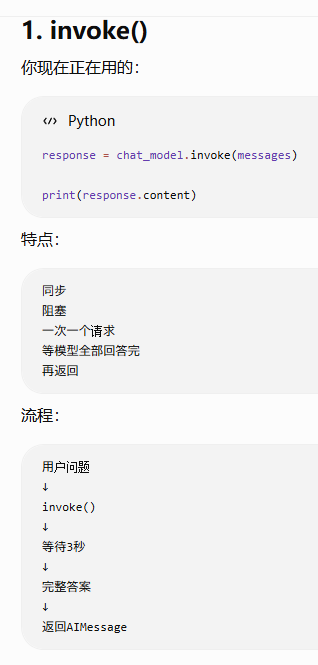

举例2：流式的演示

In [58]:
import os
import dotenv
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI

dotenv.load_dotenv()

os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")

# 初始化大模型
chat_model = ChatOpenAI(model="qwen2.5-coder:1.5b",
                        streaming=True  # 启用流式输出
                        )

# 创建消息
messages = [HumanMessage(content="你好，请介绍一下自己")]

# 流式调用LLM获取响应
print("开始流式输出：")
for chunk in chat_model.stream(messages):
    # 逐个打印内容块
    print(chunk.content, end="", flush=True) # 刷新缓冲区 (无换行符，缓冲区未刷新，内容可能不会立即显示)

print("\n流式输出结束")

开始流式输出：
您好！我是阿里云开发的角色，主要负责提供人工智能、大数据和云计算相关的产品和服务。如果您有任何问题或需要帮助，请随时告诉我，我会尽力为您提供解答和支持。
流式输出结束


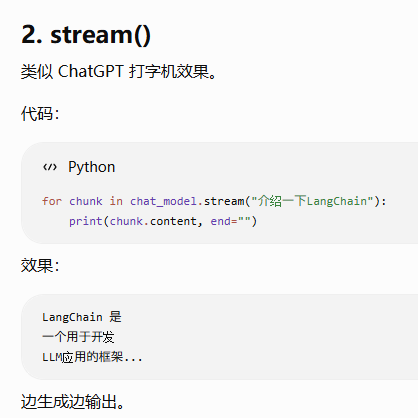

举例3：使用batch，测试批量调用

In [15]:
import os
import dotenv
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI

dotenv.load_dotenv()

os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY1")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")

# 初始化大模型
chat_model = ChatOpenAI(model="qwen2.5-coder:1.5b")

messages1 = [SystemMessage(content="你是一位乐于助人的智能小助手"),
             HumanMessage(content="请帮我介绍一下什么是机器学习"), ]

messages2 = [SystemMessage(content="你是一位乐于助人的智能小助手"),
             HumanMessage(content="请帮我介绍一下什么是AIGC"), ]

messages3 = [SystemMessage(content="你是一位乐于助人的智能小助手"),
             HumanMessage(content="请帮我介绍一下什么是大模型技术"), ]

messages = [messages1, messages2, messages3]

# 调用batch
response = chat_model.batch(messages)

print(response)


[AIMessage(content='机器学习是一种人工智能的技术，它使计算机可以从数据和模式中自动学习和改进。机器学习的基本思想是将数据输入到算法中，算法会自动学习数据的特征和模式，从而做出预测或决策。机器学习的主要应用包括自然语言处理、图像识别、欺诈检测、语音识别等。', additional_kwargs={}), AIMessage(content='AIGC全称人工智能生成内容（Artificial General Intelligence-Generated Content），是AIGC技术的一种，是指将机器模拟人类的思维和行为，生成文字、图像或音频等非结构化内容。这种技术的应用领域非常广泛，包括但不限于新闻撰写、广告制作、故事创作、虚拟演讲、多媒体制作、语音助手等。\n\n具体来说，AIGC工作原理如下：\n1. 数据训练：通过大量的文本、图像素材和其他原始数据进行深度学习和训练，构建模型以理解和生成人类的语言和行为。\n2. 用户生成：用户通过输入内容、提出问题或评论来驱动模型的生成过程。\n3. 生成内容：模型根据训练数据和用户输入生成符合设定风格和主题的文本、图像或音频。\n\nAIGC的主要优点在于可以快速生产和编辑内容，降低内容创作的复杂性和成本。然而，它也可能带来一些挑战，例如生成的内容可能不够真实、可信和符合伦理标准。因此，AIGC的发展需要结合人类的智慧和审核标准，以确保生成的内容符合伦理规范和质量标准。', additional_kwargs={}), AIMessage(content='大模型技术是指通过深度学习算法和神经网络模型将大规模的数据输入，让计算机自主学习并推断出未知事物或行为的方式。大模型技术是一种高级人工智能的技术，主要用于理解和生成人类无法用传统方式解决的问题。大模型技术可以应用于各种领域，如自然语言处理、计算机视觉、语言翻译、智能推荐、机器人等。', additional_kwargs={})]


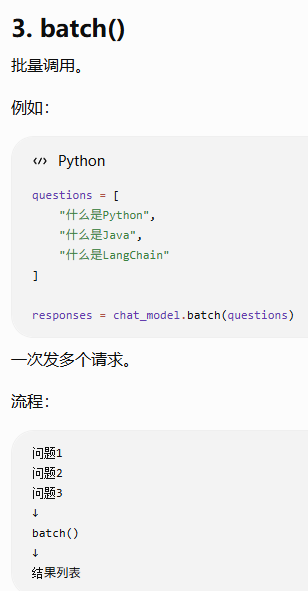

举例4：关于同步和异步方法的调用

体会1：

In [16]:
import time

def call_model():
    # 模拟同步API调用
    print("开始调用模型...")
    time.sleep(5)  # 模拟调用等待,单位：秒
    print("模型调用完成。")

def perform_other_tasks():
    # 模拟执行其他任务
    for i in range(5):
        print(f"执行其他任务 {i + 1}")
        time.sleep(1)  # 单位：秒

def main():
    start_time = time.time()
    call_model()
    perform_other_tasks()
    end_time = time.time()
    total_time = end_time - start_time
    return f"总共耗时：{total_time}秒"

# 运行同步任务并打印完成时间
main_time = main()
print(main_time)

开始调用模型...
模型调用完成。
执行其他任务 1
执行其他任务 2
执行其他任务 3
执行其他任务 4
执行其他任务 5
总共耗时：10.005311489105225秒


体会2：

In [17]:
import asyncio
import time

async def async_call(llm):
    await asyncio.sleep(5)  # 模拟异步操作
    print("异步调用完成")

async def perform_other_tasks():
    await asyncio.sleep(5)  # 模拟异步操作
    print("其他任务完成")

async def run_async_tasks():
    start_time = time.time()
    await asyncio.gather(
        async_call(None),  # 示例调用，使用None模拟LLM对象
        perform_other_tasks()
    )
    end_time = time.time()
    return f"总共耗时：{end_time - start_time}秒"

# # 正确运行异步任务的方式
# if __name__ == "__main__":
#     # 使用 asyncio.run() 来启动异步程序
#     result = asyncio.run(run_async_tasks())
#     print(result)


# 在 Jupyter 单元格中直接调用
result = await run_async_tasks()
print(result)

异步调用完成
其他任务完成
总共耗时：5.013895511627197秒


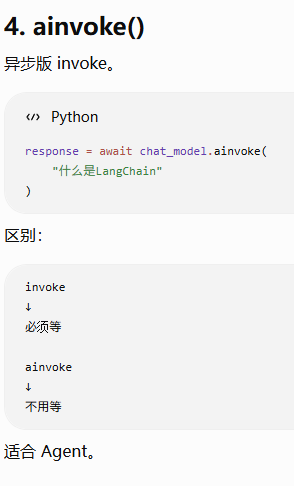

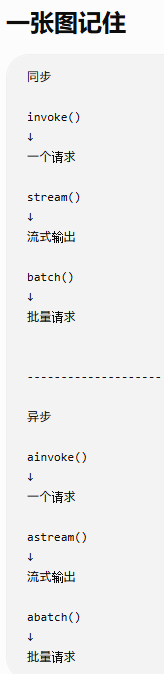